In [1]:
!pip install qutip

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 14.7 MB 14.0 MB/s 


In [2]:
 from qutip import *
 import numpy as np
 import matplotlib.pyplot as plt
 import math
 import cmath

In [3]:
bs1 = []
for i in range(3):
  bs1.append(basis(3,2-i))

print(bs1)

[Quantum object: dims = [[3], [1]], shape = (3, 1), type = ket
Qobj data =
[[0.]
 [0.]
 [1.]], Quantum object: dims = [[3], [1]], shape = (3, 1), type = ket
Qobj data =
[[0.]
 [1.]
 [0.]], Quantum object: dims = [[3], [1]], shape = (3, 1), type = ket
Qobj data =
[[1.]
 [0.]
 [0.]]]


In [4]:
bs = []

for i in range(27):
    bs.append(basis(27,(26-i)))

#print(bs[2])

In [5]:
I3 = 	qeye(3)
print(I3)

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [6]:
density1 = bs1[0].proj()
print(density1)

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 1.]]


In [7]:
density = tensor(density1, density1, density1)
#print(density)

In [8]:
sigma12 = bs1[0]*(bs1[1].dag())
sigma21 = bs1[1]*(bs1[0].dag())
M = sigma12 + sigma21
#print(M)
M_squared = M*M

In [9]:
J_12 = 5
J_23 = 10
H_dd = J_12*(tensor(sigma12,sigma21,I3) + tensor(sigma21,sigma12,I3)) + J_23*(tensor(I3,sigma12,sigma21) + tensor(I3,sigma21,sigma12))
print(H_dd)

Quantum object: dims = [[3, 3, 3], [3, 3, 3]], shape = (27, 27), type = oper, isherm = True
Qobj data =
[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. 10.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. 10.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  

In [10]:
psi0 = tensor(bs1[0],bs1[0],bs1[0])
print(psi0)

Quantum object: dims = [[3, 3, 3], [1, 1, 1]], shape = (27, 1), type = ket
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]]


In [11]:
times = np.linspace(0, 10, 100)


In [84]:
k1 = 0.5
k2 = 1
n = 1j
mn1 = tensor(bs1[1].proj(),I3,I3)
mn2 = tensor(I3,bs1[1].proj(),I3)
mn3 = tensor(I3,I3,bs1[1].proj())
ps1 = tensor(bs1[2].proj(),I3,I3)
ps2 = tensor(I3,bs1[2].proj(),I3)
ps3 = tensor(I3,I3,bs1[2].proj())
damage1 = n*(k1*mn1)/2
recovery1 = n*(k2*ps1)/2
damage2 = n*(k1*mn2)/2
recovery2 = n*(k2*ps2)/2
damage3 = n*(k1*mn3)/2
recovery3 = n*(k2*ps3)/2
H_eff = H_dd - damage1 - damage2 - damage3 - recovery1 - recovery2 - recovery3

In [85]:
omega = 5
H_eff_1 = H_eff + (omega/2)*(tensor(sigma12+sigma21,I3,I3))
#print(H_eff_1)

/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


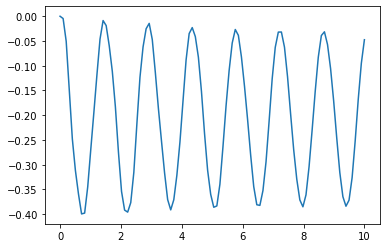

In [86]:
result7 = mesolve(H_eff_1, psi0, times, [], [(tensor(sigma21,I3,I3)*tensor(I3,I3,sigma12))])
plt.plot(result7.times, result7.expect[0])
#print(result7.expect)

In [87]:
sigma32 = bs1[2]*(bs1[1].dag())
sigma23 = bs1[1]*(bs1[2].dag())
sigma13 = bs1[0]*(bs1[2].dag())
sigma31 = bs1[2]*(bs1[0].dag())
#J1_32 = tensor(math.sqrt(k1)*sigma32,I3,I3)
#J1_32_psi = J1_32*(result5.states)
#J1_32_psi.append(J1_32*(result5.states))
#print(J1_32_psi)

In [88]:
J1_32 = tensor(math.sqrt(k1)*sigma32,I3,I3)
J2_32 = tensor(I3,math.sqrt(k1)*sigma32,I3)
J3_32 = tensor(I3,I3,math.sqrt(k1)*sigma32)
J1_13 = tensor(math.sqrt(k2)*sigma13,I3,I3)
J2_13 = tensor(I3,math.sqrt(k2)*sigma13,I3)
J3_13 = tensor(I3,I3, math.sqrt(k2)*sigma13)
print(sigma32)

#J1_32_psi.append(J1_32*(result5.states))
#print(J1_32_psi)


Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = False
Qobj data =
[[0. 1. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [89]:
delta_t = 0.001

In [90]:
times_new = np.arange(0,100,delta_t)
print(times_new)


[0.0000e+00 1.0000e-03 2.0000e-03 ... 9.9997e+01 9.9998e+01 9.9999e+01]


In [91]:
#psi_updated = []
c = 0
#c1 = 0
del_p = []
jump_where = []
jump_where1 = []
jump_which = []
psi_t = psi0
#psi_updated.append(psi_t)
for i in times_new :
  #psi_t = psi0
  expt = expect(H_eff_1-(H_eff_1.dag()),psi_t)
  delta_p = 1j*(delta_t*expt)
  epsilon = np.random.uniform(low = 0.0, high = 1.0, size = None)
  #psi_updated.append(psi_t)
  if (delta_p.real < epsilon) :
    psi_dt = (1 - 1j*(H_eff_1*delta_t))*psi_t/(math.sqrt(1-delta_p.real))
    c = c+1
    psi_t = psi_dt
    #psi_updated.append(psi_t)
  elif (delta_p.real >= epsilon) :
    #c1 = c1 + 1
    jump_where.append(i)
    #kl.append(delta_p)
    #op.append(epsilon)
    delta = np.random.uniform(low = 0.0, high = 1.0, size = None)
    delta_p1_32 = (expect(J1_32.dag()*J1_32,psi_t))*delta_t
    delta_p2_32 = (expect(J2_32.dag()*J2_32,psi_t))*delta_t
    delta_p3_32 = (expect(J3_32.dag()*J3_32,psi_t))*delta_t
    delta_p1_13 = (expect(J1_13.dag()*J1_13,psi_t))*delta_t
    delta_p2_13 = (expect(J2_13.dag()*J2_13,psi_t))*delta_t
    delta_p3_13 = (expect(J3_13.dag()*J3_13,psi_t))*delta_t
    del_p = np.array([delta_p1_32, delta_p2_32, delta_p3_32, delta_p1_13, delta_p2_13, delta_p3_13])
    #kl.append(del_p)
    J = [J1_32, J2_32, J3_32, J1_13, J2_13, J3_13]
    count = np.count_nonzero(del_p, axis=None)
    ab = np.linspace(0,1,count+1)
    zero_where = np.where(del_p != 0)[0]
    #prob = delta_p1_32+delta_p2_32+delta_p3_32+delta_p1_13+delta_p2_13+delta_p3_13
    for l in range(count) :
      if (delta >= ab[l] and delta < ab[l+1]) :
        psi_dt = ((J[zero_where[l]])*psi_t)/(cmath.sqrt(del_p[zero_where[l]]/delta_t))
        jump_where1.append(ab[l]) 
        jump_which.append(J[zero_where[l]])
        break
    psi_t = psi_dt
    #psi_updated.append(psi_t)
    #psi_t = psi0
  #psi_t = psi_dt
  #psi_updated.append(psi_t)
  

In [92]:

jump = np.zeros(100000)
for iter in range(len(jump_where)) :
  for iter1 in range(6) :
    if ((jump_which[iter] == J[iter1]) and (iter1 < 3)) :
      bn = int(jump_where[iter]*1000)
      bn_count = jump[bn]
      jump[bn:]+= 1
      break
    elif ((jump_which[iter] == J[iter1]) and (iter1 >= 3)) :
      cn = int(jump_where[iter]*1000)
      jump[cn:]-= 1
      break

print(jump)
    


[0. 0. 0. ... 1. 1. 1.]


In [93]:
jump_time = (np.count_nonzero(jump, axis=None))*delta_t
print(jump_time)
print("Damaged state percentage",jump_time,"%")
#print(np.count_nonzero(jump==0))

45.232
Damaged state percentage 45.232 %


In [94]:
jump_nonzero = jump[np.where(jump!=0)]
print(len(jump_where))

101


In [95]:
j1 = ((np.count_nonzero(jump==1))*delta_t)
j2 = ((np.count_nonzero(jump==2))*delta_t)*2
j3 = ((np.count_nonzero(jump==3))*delta_t)*3
j = j1+j2+j3
print(j)

62.413


In [96]:
print("Damaged state area in percentage",j/3,"%")

Damaged state area in percentage 20.804333333333332 %


Text(0.5, 1.0, 'Telegraph diagram of network state')

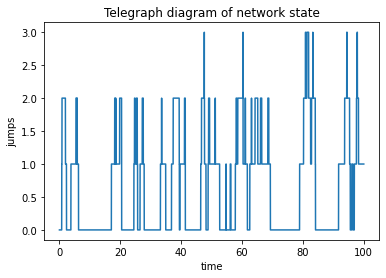

In [97]:
plt.plot(times_new, jump)
plt.xlabel('time')
plt.ylabel('jumps')
plt.title("Telegraph diagram of network state")
#plt.xlim([0,15])

In [98]:
state1 = np.zeros(100000)
state2 = np.zeros(100000)
state3 = np.zeros(100000)
for i in range(len(jump_where)) : 
  if (jump_which[i] == J[0] or jump_which[i] == J[3]) :
    bn = int(jump_where[i]*1000)
    state1[bn]+= 1
  elif (jump_which[i] == J[1] or jump_which[i] == J[4]) :
    bn = int(jump_where[i]*1000)
    state2[bn]+= 1
  else :
    bn = int(jump_where[i]*1000)
    state3[bn]+= 1


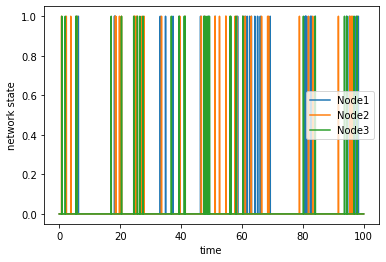

In [99]:
plt.plot(times_new, state1, times_new, state2, times_new, state3)
plt.xlabel('time')
plt.ylabel('network state')
#plt.title("Telegraph diagram of network state")
#plt.xlim([0,12])
plt.legend(['Node1', 'Node2', 'Node3'])

In [100]:
H_eff_2 = H_eff + (omega/2)*(tensor(I3,sigma12+sigma21,I3))
c = 0
#c1 = 0
del_p = []
jump_where = []
jump_where1 = []
jump_which = []
psi_t = psi0
#psi_updated.append(psi_t)
for i in times_new :
  #psi_t = psi0
  expt = expect(H_eff_2-(H_eff_2.dag()),psi_t)
  delta_p = 1j*(delta_t*expt)
  epsilon = np.random.uniform(low = 0.0, high = 1.0, size = None)
  #psi_updated.append(psi_t)
  if (delta_p.real < epsilon) :
    psi_dt = (1 - 1j*(H_eff_2*delta_t))*psi_t/(math.sqrt(1-delta_p.real))
    c = c+1
    psi_t = psi_dt
    #psi_updated.append(psi_t)
  elif (delta_p.real >= epsilon) :
    #c1 = c1 + 1
    jump_where.append(i)
    #kl.append(delta_p)
    #op.append(epsilon)
    delta = np.random.uniform(low = 0.0, high = 1.0, size = None)
    delta_p1_32 = (expect(J1_32.dag()*J1_32,psi_t))*delta_t
    delta_p2_32 = (expect(J2_32.dag()*J2_32,psi_t))*delta_t
    delta_p3_32 = (expect(J3_32.dag()*J3_32,psi_t))*delta_t
    delta_p1_13 = (expect(J1_13.dag()*J1_13,psi_t))*delta_t
    delta_p2_13 = (expect(J2_13.dag()*J2_13,psi_t))*delta_t
    delta_p3_13 = (expect(J3_13.dag()*J3_13,psi_t))*delta_t
    del_p = np.array([delta_p1_32, delta_p2_32, delta_p3_32, delta_p1_13, delta_p2_13, delta_p3_13])
    #kl.append(del_p)
    J = [J1_32, J2_32, J3_32, J1_13, J2_13, J3_13]
    count = np.count_nonzero(del_p, axis=None)
    ab = np.linspace(0,1,count+1)
    zero_where = np.where(del_p != 0)[0]
    #prob = delta_p1_32+delta_p2_32+delta_p3_32+delta_p1_13+delta_p2_13+delta_p3_13
    for l in range(count) :
      if (delta >= ab[l] and delta < ab[l+1]) :
        psi_dt = ((J[zero_where[l]])*psi_t)/(cmath.sqrt(del_p[zero_where[l]]/delta_t))
        jump_where1.append(ab[l]) 
        jump_which.append(J[zero_where[l]])
        break
    psi_t = psi_dt

In [101]:
jump = np.zeros(100000)
for iter in range(len(jump_where)) :
  for iter1 in range(6) :
    if ((jump_which[iter] == J[iter1]) and (iter1 < 3)) :
      bn = int(jump_where[iter]*1000)
      bn_count = jump[bn]
      jump[bn:]+= 1
      break
    elif ((jump_which[iter] == J[iter1]) and (iter1 >= 3)) :
      cn = int(jump_where[iter]*1000)
      jump[cn:]-= 1
      break

print(jump)
    
    


[0. 0. 0. ... 1. 1. 1.]


Text(0.5, 1.0, 'Telegraph diagram of network state')

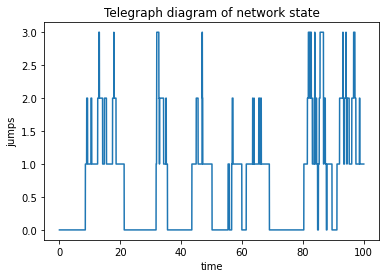

In [102]:
plt.plot(times_new, jump)
plt.xlabel('time')
plt.ylabel('jumps')
plt.title("Telegraph diagram of network state")
#plt.xlim([0,15])

In [103]:
jump_time1 = (np.count_nonzero(jump, axis=None))*delta_t
print(jump_time1)
print("Damaged state percentage",jump_time1,"%")

52.101
Damaged state percentage 52.101 %


In [104]:
j1 = ((np.count_nonzero(jump==1))*delta_t)
j2 = ((np.count_nonzero(jump==2))*delta_t)*2
j3 = ((np.count_nonzero(jump==3))*delta_t)*3
j = j1+j2+j3
print(j)

72.131


In [105]:
print("Damaged state area in percentage",j/3,"%")

Damaged state area in percentage 24.043666666666667 %


In [106]:

state1 = np.zeros(100000)
state2 = np.zeros(100000)
state3 = np.zeros(100000)
for i in range(len(jump_where)) : 
  if (jump_which[i] == J[0] or jump_which[i] == J[3]) :
    bn = int(jump_where[i]*1000)
    state1[bn]+= 1
  elif (jump_which[i] == J[1] or jump_which[i] == J[4]) :
    bn = int(jump_where[i]*1000)
    state2[bn]+= 1
  else :
    bn = int(jump_where[i]*1000)
    state3[bn]+= 1


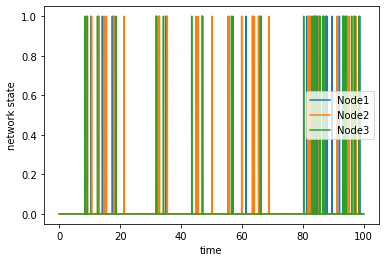

In [107]:
plt.plot(times_new, state1, times_new, state2, times_new, state3)
plt.xlabel('time')
plt.ylabel('network state')
#plt.title("Telegraph diagram of network state")
#plt.xlim([0,12])
plt.legend(['Node1', 'Node2', 'Node3'])

In [ ]:
percentages1 = np.array([67.426,72.773,64.167,66.101,67.492,63.122,63.621,65.855,61.39,72.073])
percentages2 = np.array([71.132,67.268,67.268,68.783,67.77,75.519,72.555,56.183,63.313,74.075])
print(np.mean(percentages1))
print(np.mean(percentages2))

66.402
68.38660000000002


In [ ]:
ar_percent1 = np.array([29.316,35.674,29.627,31.098,32.04,29.682,29.481,31.127,26.222,33.383])
ar_percent2 = np.array([34.834,29.653,29.653,34.808,30.116,37.914,34.684,26.137,32.757,34.03])

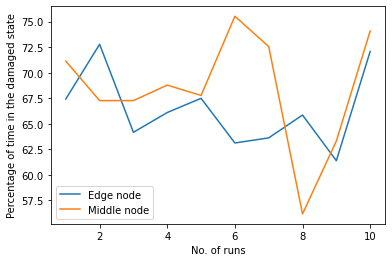

In [ ]:
runs = np.arange(1,11,1)
plt.plot(runs,percentages1,runs,percentages2)
plt.xlabel("No. of runs")
plt.ylabel("Percentage of time in the damaged state")
plt.legend(["Edge node","Middle node"])

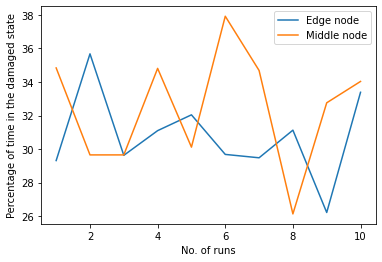

In [ ]:
plt.plot(runs,ar_percent1,runs,ar_percent2)
plt.xlabel("No. of runs")
plt.ylabel("Percentage of time in the damaged state")
plt.legend(["Edge node","Middle node"])